# Semantic Routing チューニング

## このノートブックで何をするか

Kong AI Gateway の **Semantic Routing** は、受け取ったプロンプトの意味を見て、
複数の LLM のうちどれに流すかを自動で振り分ける機能です。振り分けの基準になるのは、
各 target(振り分け先)に書いた **`description`(その target が何を担当するかの説明文)**
と、しきい値である **`threshold`** の 2 つだけです。

この 2 つは「なんとなく」設定されがちですが、実際には
**誤ったモデルに流す / 何でもフォールバック先に落ちる** といった形で品質とコストに直結します。
このノートブックは、その 2 つを**勘ではなく実測データで調整する**手順を示します。

## 前提となる仕組み(3 分で読める用語整理)

| 用語 | 意味 |
|---|---|
| **埋め込み (embedding)** | 文章を数千個の数値の並び(ベクトル)に変換したもの。意味が近い文章どうしは近い数値の並びになる。ここでは Azure OpenAI の `text-embedding-3-large` で **3072 個の数値**に変換している |
| **コサイン距離** | 2 つのベクトルがどれだけ違う向きを向いているかの指標。**0 なら同じ意味、値が大きいほど無関係**。理論上の範囲は 0〜2 |
| **`threshold`** | 「この距離までなら同じ話題とみなす」という**距離の上限(半径)**。<br>**大きくするほど採用されやすくなる**(似ていなくても通す)。似ている度合いの下限ではないので注意 |
| **`CATCHALL`** | どの target にも当てはまらなかったときの受け皿。`description` に文字列 `CATCHALL` を書いた target がこれになる |
| **ベクトル検索 (KNN)** | 大量のベクトルの中から、指定したベクトルに最も近いものを探す検索。ここでは Redis がその役割を担う |

Kong は起動後の最初のリクエストで、**各 target の `description` を埋め込みに変換して Redis に保存**します。
以降のリクエストでは、プロンプトを同じように埋め込みに変換し、
Redis の中で最も近い `description` を探して、その target に流します。

つまり **ルーティングの実体は「文章どうしの距離の比較」**です。
であれば、その距離を Kong の外側で再現して測れば、
**本番に一切影響を与えずに設定を検証できる**——これがこのノートブックの土台です。

## 進め方(全 6 セクション)

| | やること | これで何が分かるか |
|---|---|---|
| 1 | 本番相当の Redis から sandbox へベクトルを複製 | 本番を触らずに実験できる状態を作る |
| 2 | Kong が作ったベクトルと我々のベクトルが一致するか検証 | **オフラインでの検証が本番と同じ結果になる保証**を得る |
| 3 | 評価用のデータ 40 件でベクトル検索を実行 | 「実際どこに振り分けられるか」を一件ずつ観測する |
| 4 | 現状の設定を採点し、しきい値を掃引して可視化 | **今の設定がどれだけ外しているか**を数字にする |
| 5 | `description` を書き換えて即再評価し、比較する | しきい値の問題か説明文の問題かを**切り分ける** |
| 6 | 結論を Langfuse に記録し、`kong.yaml` への差分を出す | 判断の根拠を残し、本番へ反映する |

## 実行前の前提

`mise run docker:restart` と `mise run deck:sync` が済んでおり、
Kong に 1 度以上リクエストが流れていること
(**ベクトルは Kong の起動時ではなく初回リクエスト時に書き込まれる**ため)。

In [3]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import redis

from semtune.config import DATA_DIR, load_golden_dataset, load_routing_config
from semtune.embed import Embedder, cosine_distance
from semtune.evaluate import distance_distribution, evaluate, sweep
from semtune.search import decide, knn
from semtune.vectors import (
    create_eval_index,
    discover_index,
    migrate,
    read_vector,
    upsert_target_vector,
)

# redis-py 8.1.0 は既定で RESP3 を話す。RESP3 だと FT.INFO / FT.SEARCH の生レスポンスが
# 辞書型になり、semtune.vectors.parse_ft_info / semtune.search.knn が前提とするフラットな
# リスト構造と食い違って KeyError になる。両クライアントとも protocol=2 (RESP2) を明示する。
PROD = redis.Redis(host="127.0.0.1", port=6381, protocol=2)   # 疑似本番(Kong が使う、読み取り専用)
SANDBOX = redis.Redis(host="127.0.0.1", port=6380, protocol=2)  # sandbox(ここで実験する)

config = load_routing_config(DATA_DIR / "routing_targets.yaml")
cases = load_golden_dataset(DATA_DIR / "golden_dataset.yaml", config)

embedder = Embedder(
    config.embeddings,
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    cache_dir=Path(".cache/embeddings"),
)

print(f"targets: {config.target_names()}")
print(f"threshold: {config.threshold}")
print(f"cases: {len(cases)}")


targets: ['market-research', 'dev-support', 'general']
threshold: 0.5
cases: 40


上のセルで用意したもの:

- **`PROD`(ポート 6381)** — Kong が実際に使っている Redis。本番相当。**このノートブックでは一切書き込みません**
- **`SANDBOX`(ポート 6380)** — 実験用の空の Redis。書き換えはすべてこちら
- **`config`** — `routing_targets.yaml` から読んだ target 定義としきい値。`kong.yaml` の設定と同じ内容を持つ
- **`cases`** — Golden Dataset(正解ラベル付きの評価用クエリ 40 件)
- **`embedder`** — Azure OpenAI の埋め込み API クライアント。**Kong が内部で使うのと同一のモデル・同一の次元数**を使う

出力の `threshold: 0.5` が、現在 `kong.yaml` に入っている本番の設定値です。
これが妥当かどうかを、このあと実データで検証します。

## 1. 疑似本番から sandbox へベクトルを移送する

**やること:** Kong が本番 Redis に書き込んだ target のベクトルを、実験用の sandbox へ複製します。

**なぜやるか:** 設定の検証をするたびに本番の Redis を書き換えるわけにはいきません。
一方で、検証に使うベクトルは**本番でルーティングに実際に使われているもの**でなければ意味がありません。
そこで「本番からは読むだけ、書き込みは sandbox だけ」という形にします。

実運用では、この移送元が本番の Redis になります。
本番が他システムと相乗りしていても、**対象のキーだけを選んで抜ける**方式を採っています。

In [4]:
spec = discover_index(PROD)
spec


IndexSpec(index='idx:vss_semantic_routing:fb3402db-e00f-4c6f-9a5d-b11b9e2d933e:route', prefix='semantic_routing:fb3402db-e00f-4c6f-9a5d-b11b9e2d933e:route:', dimensions=3072, distance_metric='COSINE', storage='JSON')

`discover_index` は Redis に登録されている検索インデックスの一覧を問い合わせ、
Kong が semantic routing 用に作ったものを見つけ出します。

出力を読むと、Kong が内部でどういう構造を作っているかが分かります。

- **`index`** — インデックス名。`idx:vss_semantic_routing:<プラグインのUUID>:route` という形。
  UUID が入るので**設定ファイルから決め打ちできず、必ず問い合わせて見つける**必要があります
- **`prefix`** — ベクトルを格納するキーの接頭辞
- **`dimensions: 3072`** — 1 つのベクトルが 3072 個の数値でできていること。
  `kong.yaml` の `vectordb.dimensions` と一致します
- **`distance_metric: COSINE`** — 距離の測り方。`kong.yaml` の `distance_metric: cosine` と一致します

ここが `kong.yaml` の設定と食い違っていれば、その時点で設定ミスが発覚します。

In [5]:
prod_keys = [k.decode() for k in PROD.scan_iter(match=f"{spec.prefix}*")]
prod_keys


['semantic_routing:fb3402db-e00f-4c6f-9a5d-b11b9e2d933e:route:7d9f9804601ab53de61f9404f83a6af781c3bd8ca4c5cd4b3a949b32fb0d37e7',
 'semantic_routing:fb3402db-e00f-4c6f-9a5d-b11b9e2d933e:route:49796037f96ead24e8986c4dcd7c61e453d6c1d117c793db11e5f01b08108f92']

Kong が保存したベクトルのキー一覧です。ここには**説明する価値のある事実が 2 つ**あります。

**1. キーの末尾は `description` のハッシュ値です。**
Kong は各 target の `description` の SHA-256 を計算してキー名にしています。
つまり **`description` を 1 文字でも変えれば別のキーになり、ベクトルも作り直されます**。
逆に言えば、説明文を変えるということは、ルーティングの基準そのものを差し替えるということです。

**2. キーは 3 つではなく 2 つです。**
target は 3 つ設定していますが、`CATCHALL` の target についてだけベクトルが保存されていません。
`CATCHALL` は「どれにも当てはまらなかったときの受け皿」であり、
**距離を比べる対象ではなく、比較に負けたときの行き先**だからです。

In [6]:
report = migrate(PROD, SANDBOX, spec)
report


MigrationReport(index='idx:vss_semantic_routing:fb3402db-e00f-4c6f-9a5d-b11b9e2d933e:route', keys_copied=2, verified=True, message='copied 2 keys and verified')

移送結果です。`keys_copied` が本番側のキー数と一致し、`verified=True` であれば成功です。

`verified` は 2 つの確認を通ったことを意味します。

1. 移送先のキー数が移送元と一致すること
2. 抜き取った 1 件が**バイト単位で完全一致**すること(ベクトルは浮動小数点の塊なので、
   目視ではなく機械的に照合します)

この時点で sandbox には、本番と同じベクトルが同じ構造で入っています。
以降の操作はすべて sandbox に対して行い、本番側は読み取りすらしません。

## 2. 埋め込み経路の等価性を検証する

**このセクションが、このノートブック全体の信頼性を支えています。**

これから先、私たちは Kong の外側で「この設定ならどこに振り分けられるはずだ」と計算します。
しかしその計算が、Kong が実際に内部でやっていることと**少しでもずれていたら、
以降の数字はすべて意味を失います**。

そこで先に証明しておきます。やることは単純です。

1. Kong が本番 Redis に保存したベクトル(Section 1 で移送してきたもの)を読み出す
2. 同じ `description` を、我々が Azure OpenAI の同じモデル・同じ次元数で埋め込みに変換する
3. **両者のコサイン距離を測る**

この距離が 0 に極めて近ければ、**「Kong が内部で作るベクトル」と「我々が作るベクトル」は
同一である**と機械的に言い切れます。つまり本番を動かさずに本番の挙動を推論してよい、
という許可が得られます。

同時に、埋め込みの次元数が Redis のインデックスの次元数と一致するかも `assert` で検査しています。
ここが食い違ったまま先に進むと、もっともらしい数字が出るのに全部間違っている、
という最悪の壊れ方をするためです。

In [7]:
target_vectors = embedder.embed([t.description for t in config.targets])
print("shape:", target_vectors.shape)
assert target_vectors.shape[1] == spec.dimensions, (
    f"次元不一致: 埋め込み {target_vectors.shape[1]} vs index {spec.dimensions}"
)

# Kong は general(CATCHALL, description="CATCHALL")のベクトルを Redis に書き込まない
# (README「注意」参照)。したがって catchall は「本番ベクトルと一致し得ない候補」であり、
# 含めても argmin の結果は変わらない(CATCHALL という文字列の埋め込みは他の 3 target と
# 意味的に無関係なので常に負ける)が、比較対象として意味を持たないので明示的に外す。
catchall_for_check = config.catchall_name()
comparable_targets = [
    (t, v) for t, v in zip(config.targets, target_vectors) if t.name != catchall_for_check
]

rows = []
for key in prod_keys:
    kong_vector = read_vector(SANDBOX, key)
    distances = [cosine_distance(kong_vector, v) for _, v in comparable_targets]
    nearest = int(np.argmin(distances))
    rows.append(
        {
            "kong_key": key.split(":")[-1][:12],
            "matched_target": comparable_targets[nearest][0].name,
            "distance": distances[nearest],
        }
    )

pd.DataFrame(rows)


shape: (3, 3072)


,kong_key,matched_target,distance
0,7d9f9804601a,market-research,0.000000e+00
1,49796037f96e,dev-support,-2.220446e-16


### 読み方

`distance` 列がすべて **0 に極めて近い**ことを確認してください
(過去の計測では最大 8.99e-07、およそ 1000 万分の 1 だった)。

浮動小数点の丸め誤差の範囲であり、実質的に完全一致です。
これで **「同じモデル・同じ次元数で埋め込みを作れている」ことが数値で証明できました。**

`matched_target` 列は、本番の各ベクトルがどの target の説明文に対応するかを示しています。
本番の Redis には target 名が保存されていない(ハッシュ値しか入っていない)ため、
**距離を測ることで対応付けを復元している**点も、この表が示していることの 1 つです。

## 3. 評価用 index を作り、Golden Dataset で近傍探索する

**やること:** 評価専用の検索インデックスを別に作り、そこに対して評価用クエリ 40 件を投げます。

**なぜ別のインデックスを作るか:** Section 1 で移送してきた本番の複製は、
「本番が今どうなっているか」の記録として手を付けずに残しておきたいからです。
実験は別の入れ物でやります。これにより **`description` を何十通り書き換えても、
本番の複製は汚れません**。

### Golden Dataset とは

**正解ラベル付きの評価用クエリ集**です。ここでは日本語 40 件を用意しています。

| 区分 | 件数 | 内容 |
|---|---|---|
| `easy` | 30 件(各 target 10 件) | どの target に流れるべきか迷いようがないクエリ |
| `boundary` | 10 件 | **意図的に判断が割れるように作った境界事例**。なぜそのラベルにしたかの理由を 1 件ずつ書いてある |

`boundary` を混ぜているのは、`easy` だけでは満点が出てしまい**調整の効果が見えないから**です。
実際の業務で問い合わせが集まるのは、むしろこの境界領域です。

実運用では、この Golden Dataset を **Langfuse に蓄積された実トラフィックのログから作る**
ことになります(Section 6 で触れます)。

In [8]:
eval_spec = create_eval_index(SANDBOX, config)

for target, vector in zip(config.targets, target_vectors, strict=True):
    upsert_target_vector(SANDBOX, eval_spec, target.name, vector)

SANDBOX.execute_command("FT.INFO", eval_spec.index)[:8]


[b'index_name',
 b'idx:vss_semtune',
 b'index_options',
 [],
 b'index_definition',
 [b'key_type',
  b'JSON',
  b'prefixes',
  [b'semtune:'],
  b'default_score',
  b'1',
  b'indexes_all',
  b'false'],
 b'attributes',
 [[b'identifier',
   b'$.vector',
   b'attribute',
   b'vector',
   b'type',
   b'VECTOR',
   b'algorithm',
   b'FLAT',
   b'data_type',
   b'FLOAT32',
   b'dim',
   3072,
   b'distance_metric',
   b'COSINE']]]

評価用インデックスに、3 つの target の `description` から作ったベクトルを登録しました。

出力は Redis のインデックス定義の先頭部分です。
`ON JSON` `PREFIX` といった項目が、Section 1 で見た Kong 自身のインデックスと同じ構造であることを確認できます。
**Kong と同じ土俵を、こちら側に再現している**ということです。

In [9]:
query_vectors = embedder.embed([c.query for c in cases])

hits_by_case = {
    case.id: knn(SANDBOX, eval_spec.index, vector, k=len(config.targets))
    for case, vector in zip(cases, query_vectors, strict=True)
}

pd.DataFrame(
    [
        {
            "case_id": case.id,
            "query": case.query[:32],
            "expected": case.expected,
            "top1": hits_by_case[case.id][0].target,
            "top1_distance": round(hits_by_case[case.id][0].distance, 4),
        }
        for case in cases
    ]
).head(20)


,case_id,query,expected,top1,top1_distance
0,mr-001,今週の日銀金融政策決定会合の結果が円相場に与える影響を教えて,market-research,market-research,0.5621
1,mr-002,米国の雇用統計が予想を上回った場合、長期金利はどう動く見込みか,market-research,market-research,0.6011
2,mr-003,直近の日経平均の調整局面について、業種別の寄与度をまとめて,market-research,market-research,0.5813
3,mr-004,半導体セクターの2026年度業績見通しをアナリストレポートから要,market-research,market-research,0.5791
4,mr-005,ユーロ円の3か月先のレンジ予想と、その根拠となる材料を整理して,market-research,market-research,0.5348
5,mr-006,原油価格の上昇が国内インフレ率に与える影響を試算して,market-research,market-research,0.6568
6,mr-007,米国債イールドカーブの形状変化から読み取れる景気シグナルを解説し,market-research,market-research,0.5492
7,mr-008,新興国通貨のボラティリティが高まっている背景を説明して,market-research,market-research,0.6292
8,mr-009,国内REIT市場の資金流出入の直近トレンドを要約して,market-research,market-research,0.5345
9,mr-010,決算説明会資料から、当該企業の来期ガイダンスの前提条件を抜き出し,market-research,market-research,0.6310


### 読み方

Golden Dataset の 40 件それぞれについて、ベクトル検索を実行した結果です(先頭 20 件を表示)。

| 列 | 意味 |
|---|---|
| `expected` | **人間が付けた正解**。この target に流れるべき |
| `top1` | ベクトル検索で**最も近かった** target |
| `top1_distance` | その距離。**小さいほど近い** |

ここで注意していただきたいのは、**この表はまだ「振り分け結果」ではない**ということです。
`top1` はあくまで「最も近かった候補」であり、
この距離が `threshold` を超えていれば、Kong は採用せず `CATCHALL` に落とします。

`top1_distance` の値を眺めてみてください。**多くが現在の `threshold`(0.5)を超えていないか**を
確認してください。超えていれば、この時点で何が起きるかの予兆が見えています。

## 4. 初期状態を評価する

**やること:** 現在の本番設定(`threshold = 0.5`、`description` は現行のまま)で、
Golden Dataset 40 件がどこに振り分けられるかを採点します。

### 3 つの指標の読み方

| 指標 | 意味 | 高いほど良いか |
|---|---|---|
| **accuracy** | 40 件のうち、正解の target に振り分けられた割合 | 高いほど良い |
| **boundary accuracy** | **境界事例 10 件だけ**を取り出した正解率。判断が割れるクエリをどれだけ捌けているか | 高いほど良い |
| **fallback rate** | `CATCHALL` に落ちた割合。**どの target にも当てはまらないと判定された割合** | **低いほど良い**(ただし 0 が最良とは限らない) |

`fallback rate` を分けて見るのが重要です。
accuracy が低いとき、原因が「**別の target に間違えて流している**」のか
「**そもそも何も選べていない**」のかで、打つべき手がまったく変わるからです。

### 混同行列の読み方

下に出る表は **行が正解、列が実際の振り分け先**です。
対角線上(行と列が同じところ)にあるのが正解した件数、
それ以外の場所にあるのが間違えた件数です。

In [10]:
catchall = config.catchall_name()
decisions = [decide(hits_by_case[c.id], config.threshold, catchall) for c in cases]
result = evaluate(cases, decisions, config.target_names())

print(f"accuracy           : {result.accuracy:.1%}")
print(f"boundary accuracy  : {result.boundary_accuracy:.1%}")
print(f"fallback rate      : {result.fallback_rate:.1%}")
result.confusion


accuracy           : 35.0%
boundary accuracy  : 40.0%
fallback rate      : 100.0%


,market-research,dev-support,general
market-research,0,0,13
dev-support,0,0,13
general,0,0,14


In [11]:
result.mistakes

,case_id,query,expected,actual,difficulty,top1_distance,margin
0,mr-001,今週の日銀金融政策決定会合の結果が円相場に与える影響を教えて,market-research,general,easy,0.562138,0.329182
1,mr-002,米国の雇用統計が予想を上回った場合、長期金利はどう動く見込みか,market-research,general,easy,0.601122,0.279079
2,mr-003,直近の日経平均の調整局面について、業種別の寄与度をまとめて,market-research,general,easy,0.581282,0.223206
3,mr-004,半導体セクターの2026年度業績見通しをアナリストレポートから要約して,market-research,general,easy,0.579137,0.184965
4,mr-005,ユーロ円の3か月先のレンジ予想と、その根拠となる材料を整理して,market-research,general,easy,0.534770,0.268762
5,mr-006,原油価格の上昇が国内インフレ率に与える影響を試算して,market-research,general,easy,0.656766,0.173374
6,mr-007,米国債イールドカーブの形状変化から読み取れる景気シグナルを解説して,market-research,general,easy,0.549187,0.316423
7,mr-008,新興国通貨のボラティリティが高まっている背景を説明して,market-research,general,easy,0.629174,0.240884
8,mr-009,国内REIT市場の資金流出入の直近トレンドを要約して,market-research,general,easy,0.534472,0.310941
9,mr-010,決算説明会資料から、当該企業の来期ガイダンスの前提条件を抜き出して,market-research,general,easy,0.631004,0.172819


### 誤りの一覧

間違えたクエリを 1 件ずつ並べたものです。デモではこの表を実際に読み上げると効果的です。

| 列 | 意味 |
|---|---|
| `expected` / `actual` | 正解と、実際の振り分け先 |
| `top1_distance` | 最も近かった候補までの距離 |
| `margin` | **1 位と 2 位の距離の差** |

`margin` を出しているのは、**「僅差で外した」のか「まったく別物と判定された」のかを
区別するため**です。僅差なら説明文の微調整で救える見込みがありますが、
大きく離れているなら設計自体を見直す必要があります。

### 混同行列を読む前に: catchall への集中と target 間の混同を切り分ける

混同行列を見るとき、最初に確認すべきは**非対角成分がどこにあるか**である。

- `general`(CATCHALL)**列に件数が集中している** → 原因は description ではなく
  **threshold が狭すぎること**。`mistakes` の `top1_distance` を見ると、正解 target との
  距離が `threshold` の半径に収まっていないはずである。この状態では「どの候補が最も近かったか」
  が threshold の外側で切り捨てられており、target 同士が互いに紛らわしいかどうかを
  混同行列だけからは判断できない
- **target 同士の非対角成分が立っている** → こちらは description 由来の混同であり、
  説明文を書き直す対象になる

前者であるうちは、最初に直すべきはまず threshold であって description ではない。
次の sweep で threshold を広げていくと catchall への逃げ場が塞がれ、
そこで初めて「どの target 同士が本当に紛らわしいか」が混同行列に現れてくる
(Section 5 で確認する)。


### threshold の掃引 (sweep)

**やること:** `threshold` を 0.00 から 1.00 まで 0.01 刻みで動かし、
それぞれの値で 40 件を採点し直します。**埋め込みも検索もやり直さず**、
既に測った距離に対してしきい値だけを変えるので、一瞬で終わります。

**なぜやるか:** `threshold` は「ここが正解」という値が事前に分かるものではありません。
**実際に動かしてみて、どこで性能が最大になるかを見る**しかありません。
このグラフは、その全体像を 1 枚で示します。

### グラフの読み方

- **横軸** — `threshold`(コサイン距離の上限)。**右に行くほど「似ていなくても通す」ゆるい設定**
- **青 accuracy** — 全体の正解率
- **橙 boundary accuracy** — 境界事例だけの正解率
- **緑 fallback rate** — `CATCHALL` に落ちた割合
- **灰色の破線** — 現在の本番設定値(0.5)

しきい値を上げていくと `fallback rate` は必ず下がります(何でも通すようになるため)。
しかし上げすぎると今度は**間違った target にも通してしまう**ので、accuracy はどこかで頭打ちになり、
やがて下がります。**その頂点を探すのがこのグラフの目的**です。

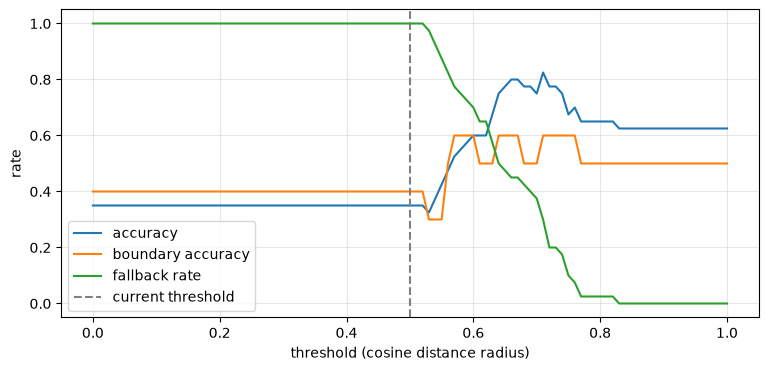

best threshold: 0.71 (accuracy 82.5%)


In [12]:
thresholds = [round(x, 2) for x in np.arange(0.0, 1.01, 0.01)]
sweep_df = sweep(cases, hits_by_case, thresholds, catchall, config.target_names())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sweep_df["threshold"], sweep_df["accuracy"], label="accuracy")
ax.plot(sweep_df["threshold"], sweep_df["boundary_accuracy"], label="boundary accuracy")
ax.plot(sweep_df["threshold"], sweep_df["fallback_rate"], label="fallback rate")
ax.axvline(config.threshold, color="gray", linestyle="--", label="current threshold")
ax.set_xlabel("threshold (cosine distance radius)")
ax.set_ylabel("rate")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

best = sweep_df.loc[sweep_df["accuracy"].idxmax()]
print(f"best threshold: {best['threshold']} (accuracy {best['accuracy']:.1%})")


### この掃引が示したこと

灰色の破線(現在の設定値 0.5)の位置と、accuracy 曲線の頂点の位置を見比べてください。
破線が頂点から離れているほど、**`description` を 1 文字も変えずに、しきい値を動かすだけで
改善できる余地が残っている**ということです。

ただし、これで結論を出すのはまだ早すぎます。
「しきい値さえ直せば十分なのか、説明文にも問題があるのか」を切り分ける必要があります。
それを次の距離分布で判定します。


### 距離分布 — 「しきい値の問題」と「説明文の問題」を切り分ける

**このグラフが、このノートブックで最も実務的な図です。**

**やること:** 全クエリについて、
**正解 target との距離**と**不正解 target との距離**を、それぞれヒストグラムにして重ねます。

**なぜやるか:** `threshold` というのは、この横軸のどこかに 1 本線を引く操作にすぎません。
つまり:

- **2 つの山が左右に分かれている** → その間に線を引けば正しく分離できる。
  **これは「しきい値の問題」であり、`threshold` を調整すれば解決する**
- **2 つの山が重なっている** → その重なった領域では、線をどこに引いても
  正解と不正解が混ざる。**これは「説明文の問題」であり、`threshold` では解決できない。
  `description` を書き直して山を引き離すしかない**

設定をいじる前にこの図を見ることで、**打つべき手が最初から決まります。**
これが「勘で調整する」のと「データで調整する」の違いです。

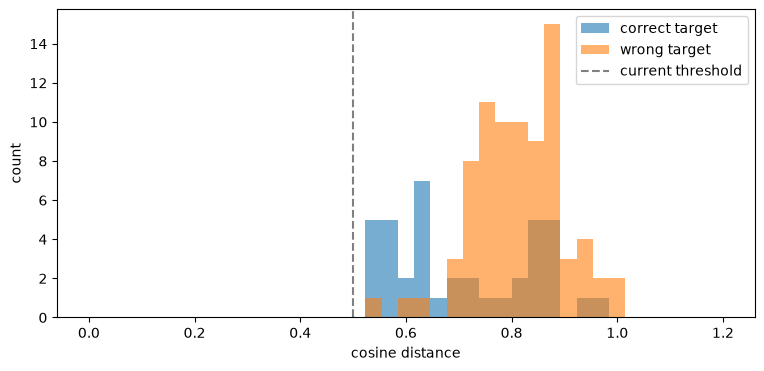

In [13]:
dist_df = distance_distribution(cases, hits_by_case)

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 1.2, 40)
ax.hist(
    dist_df[dist_df["is_correct_target"]]["distance"],
    bins=bins, alpha=0.6, label="correct target",
)
ax.hist(
    dist_df[~dist_df["is_correct_target"]]["distance"],
    bins=bins, alpha=0.6, label="wrong target",
)
ax.axvline(config.threshold, color="gray", linestyle="--", label="current threshold")
ax.set_xlabel("cosine distance")
ax.set_ylabel("count")
ax.legend()
plt.show()


### この分布の読み方

2 つの山が**左右にずれている**なら、適切な位置に線を引けばかなりの部分は分離できます。

そして灰色の破線(現在の 0.5)の位置を見てください。
これが**正解ペアの山より左に寄っている**なら、正解の大半がしきい値の外に出て
`CATCHALL` に落ちます。Section 4 で見たフォールバックの多さは、この図で言えば
**線を引く位置が左に寄りすぎている**という一言に尽きます。

同時に、2 つの山に**重なっている領域**が残っていれば、
そこは `threshold` では救えない部分であり、`description` の改善余地です。
次のセクションで、実際に書き換えて効果を測ります。


## 5. description を書き換えて即座に再評価する

sandbox の評価用 index を上書きするだけなので、Kong の再デプロイは不要。
ここで案を何通りでも試せる。

`market-research` と `dev-support` は語彙としては遠いが、**題材と成果物が食い違うクエリ**
(「株価データから移動平均を計算するコードを書いて」「相場データの取り込みバッチが遅い」)
では取り違えが起きる。boundary 事例はまさにそこを突いている。
以下の revised description は単なる言い換えではなく、次の 2 点を明示的に足している。

- `market-research`: 担当するのは**相場・経済そのものの解釈**であることを明記し、
  データの取得方法や集計・可視化の「実装」は扱わない、という除外の一文を追加した。
- `dev-support`: **扱うデータが市場データであっても、成果物がコードや調査手順であれば
  こちらが担当する**という判断基準を明記し、逆に文書作成や一般的な PC 操作は扱わない
  ことを追加した。


In [14]:
def evaluate_descriptions(
    descriptions: dict[str, str],
    threshold: float,
    index: str = "idx:vss_semtune",
    prefix: str = "semtune:",
):
    """target 名 -> description の辞書を受け取り、その条件で評価する。

    index/prefix は create_eval_index の既定値のままにしていない。Section 3 の
    baseline 評価も同じ既定値(idx:vss_semtune / semtune:)を使っているため、
    ここでも既定値のまま呼ぶと Section 3 の baseline 用 index を revised の
    ベクトルで上書きしてしまう。すると Section 4 の baseline 検索セルだけを
    Section 5 実行後に単独で再実行した場合、エラーも警告も出さずに revised
    ベクトルに対する検索結果を返してしまう(top-to-bottom 実行では baseline の
    hits を先にメモリへ確保しているので問題は起きないが、リハーサル中に
    このセルだけ再実行すると気付かずに数字がずれる)。そのため呼び出し側で
    baseline とは別の index/prefix を明示的に渡す。
    """
    names = list(descriptions.keys())
    vectors = embedder.embed([descriptions[n] for n in names])

    spec = create_eval_index(SANDBOX, config, index=index, prefix=prefix)
    for name, vector in zip(names, vectors, strict=True):
        upsert_target_vector(SANDBOX, spec, name, vector)

    qv = embedder.embed([c.query for c in cases])
    hits = {
        case.id: knn(SANDBOX, spec.index, vector, k=len(names))
        for case, vector in zip(cases, qv, strict=True)
    }
    ds = [decide(hits[c.id], threshold, catchall) for c in cases]
    return evaluate(cases, ds, names), hits, ds


def evaluate_at_threshold(hits_by_case, threshold, target_names):
    """既に計算済みの hits に対して threshold だけを変えて再評価する(埋め込み・KNN は再実行しない)。"""
    ds = [decide(hits_by_case[c.id], threshold, catchall) for c in cases]
    return evaluate(cases, ds, target_names)


baseline_descriptions = {t.name: t.description for t in config.targets}
revised_descriptions = dict(baseline_descriptions)
revised_descriptions["market-research"] = (
    "相場・経済そのものの解釈を担当する。金利・為替・株式・債券・コモディティの値動きの解釈、"
    "経済指標やアナリストレポートの読み解き、決算資料からの業績見通しの抽出を含む。"
    "データの取得方法や集計・可視化の実装、ツールの使い方は扱わない。"
)
revised_descriptions["dev-support"] = (
    "ソフトウェア開発の実作業を担当する。コード生成とレビュー、SQLと実行計画の改善、"
    "バッチやジョブの障害調査、テスト設計、エラーメッセージの技術的な解釈を含む。"
    "扱うデータが市場データであっても、成果物がコードや調査手順であればこちらが担当する。"
    "文書作成や一般的なPC操作の質問は扱わない。"
)

revised_result, revised_hits, revised_decisions = evaluate_descriptions(
    revised_descriptions,
    config.threshold,
    index="idx:vss_semtune_revised",
    prefix="semtune_revised:",
)


In [15]:
# threshold を 0.5 に固定したまま比べると revised が良く見えるが、それは threshold
# の効果を description の効果と混同している可能性がある。そこで、baseline / revised
# それぞれについて「現行 threshold=0.5」と「そのしきい値の下で最良の threshold」の
# 両方を並べる。これが本来切り分けたかった問いそのもの: 良くなったのは
# description のおかげか、それとも単に threshold を動かしただけで得られる改善か。
revised_sweep = sweep(cases, revised_hits, thresholds, catchall, list(revised_descriptions.keys()))

baseline_best = sweep_df.loc[sweep_df["accuracy"].idxmax()]
revised_best = revised_sweep.loc[revised_sweep["accuracy"].idxmax()]

baseline_at_best = evaluate_at_threshold(
    hits_by_case, float(baseline_best["threshold"]), config.target_names()
)
revised_at_best = evaluate_at_threshold(
    revised_hits, float(revised_best["threshold"]), list(revised_descriptions.keys())
)

comparison = pd.DataFrame(
    [
        {
            "revision": "baseline",
            "threshold": config.threshold,
            "accuracy": result.accuracy,
            "boundary_accuracy": result.boundary_accuracy,
            "fallback_rate": result.fallback_rate,
        },
        {
            "revision": "baseline",
            "threshold": float(baseline_best["threshold"]),
            "accuracy": baseline_at_best.accuracy,
            "boundary_accuracy": baseline_at_best.boundary_accuracy,
            "fallback_rate": baseline_at_best.fallback_rate,
        },
        {
            "revision": "revised",
            "threshold": config.threshold,
            "accuracy": revised_result.accuracy,
            "boundary_accuracy": revised_result.boundary_accuracy,
            "fallback_rate": revised_result.fallback_rate,
        },
        {
            "revision": "revised",
            "threshold": float(revised_best["threshold"]),
            "accuracy": revised_at_best.accuracy,
            "boundary_accuracy": revised_at_best.boundary_accuracy,
            "fallback_rate": revised_at_best.fallback_rate,
        },
    ]
)
comparison


,revision,threshold,accuracy,boundary_accuracy,fallback_rate
0,baseline,0.50,0.350,0.4,1.000
1,baseline,0.71,0.825,0.6,0.300
2,revised,0.50,0.375,0.5,0.975
3,revised,0.71,0.700,0.5,0.400


### どちらを採用すべきか: threshold 固定の比較には騙されない

上の 4 行は、**同じ 2 つの description 案を、2 通りのしきい値の当て方で採点したもの**です。
読む順番は次の通り。

1. **`threshold=0.5` に固定した 2 行を比べる。** ここで revised が勝っていても、
   それは「現行のしきい値の下では」という条件付きの勝ちにすぎません。
2. **それぞれの最良 threshold の 2 行を比べる。** これが本来の比較です。
   sweep 曲線の頂点どうしを突き合わせているので、しきい値の効果を差し引いた上で
   description の効果だけを見ていることになります。
3. **1 と 2 で勝者が入れ替わっていないかを確認する。** 入れ替わっていれば、
   **固定した threshold での比較が誤った結論を導いていた**ということです。

> **未計測**: 現在の 3 target 構成では、この 4 行の実測値をまだ取っていません。
> 実行して出た値をここに書き戻し、結論(どちらを推奨するか、その理由)を
> 上の 3 ステップに沿って明文化してください。

判断の指針として、accuracy と boundary_accuracy が逆方向に動いた場合は
**トレードオフであり一方的な勝ちではありません**。
どちらを重く見るかは、実際に流れてくるクエリが境界領域に偏っているかどうかで決めます。


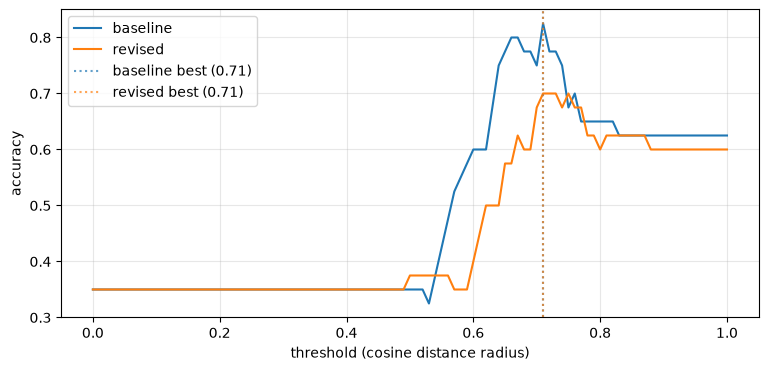

best threshold (baseline): 0.71 (accuracy 82.5%)
best threshold (revised) : 0.71 (accuracy 70.0%)


In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sweep_df["threshold"], sweep_df["accuracy"], label="baseline")
ax.plot(revised_sweep["threshold"], revised_sweep["accuracy"], label="revised")
ax.axvline(
    float(baseline_best["threshold"]), color="C0", linestyle=":", alpha=0.7,
    label=f"baseline best ({baseline_best['threshold']})",
)
ax.axvline(
    float(revised_best["threshold"]), color="C1", linestyle=":", alpha=0.7,
    label=f"revised best ({revised_best['threshold']})",
)
ax.set_xlabel("threshold (cosine distance radius)")
ax.set_ylabel("accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"best threshold (baseline): {baseline_best['threshold']} (accuracy {baseline_best['accuracy']:.1%})")
print(f"best threshold (revised) : {revised_best['threshold']} (accuracy {revised_best['accuracy']:.1%})")


## 6. 結果を Langfuse に記録し、Kong に反映する

**やること:** ここまでの評価結果を Langfuse に記録し、`kong.yaml` に適用すべき差分を出力します。

### なぜ記録を残すか

設定変更それ自体は 1 行の書き換えですが、**「なぜその値にしたのか」が残っていないと、
半年後に誰も触れなくなります。** どの Golden Dataset に対して、どの条件で、
どういう数字が出たから、この値を選んだ——これを成果物として残します。

実運用ではこの役割を Databricks のような実験管理基盤が担う想定ですが、
本デモでは代替として Langfuse を使っています。

### 将来こうつながります

Kong のトレースは既に Langfuse へ送られています。
つまり **実際に流れたプロンプトが Langfuse に蓄積されていきます**。

そこから実クエリを拾い、人手でラベルを付けて Golden Dataset に追加すれば、
**このノートブックの評価ループがそのまま継続的なチューニング基盤になります。**
今回は 40 件の手書きデータセットですが、運用が回り始めれば
実トラフィックに裏打ちされたデータセットへ育てられる、というのがこの構成の狙いです。

In [17]:
from langfuse import Langfuse
from langfuse.api.core.api_error import ApiError

from semtune.langfuse_sync import DATASET_NAME, push_dataset, push_run

lf = Langfuse(
    public_key="pk-123456789",
    secret_key="sk-123456789",
    host="http://localhost:3000",
)

push_dataset(lf, cases)


def reset_run(client, run_name: str) -> None:
    """このセルを再実行しても push_run が安全に通るように、同名の run を先に消す。

    push_run() は同名の dataset run が既にあると ValueError を送出する(意図的な安全装置。
    黙って重複させると run item とスコアが二重に記録されるため)。デモ中にこのセルを
    再実行すると必ずこのガードに当たるので、ここで明示的に「既存の run を削除してから
    作り直す」。run がまだ存在しない場合は delete が 404 の ApiError を返すだけなので、
    それは正常系として無視する。それ以外のエラーはそのまま送出する。
    """
    try:
        client.delete_dataset_run(dataset_name=DATASET_NAME, run_name=run_name)
        print(f"deleted existing run: {run_name}")
    except ApiError as e:
        if e.status_code == 404:
            print(f"no existing run to delete: {run_name} (initial run)")
        else:
            raise


# Section 5 の結論は「固定 threshold での比較は誤った結論を導く。それぞれ自分自身に
# とっての最良 threshold で比較しなければならない」だった。したがって Langfuse にも
# frozen threshold の 2 本だけでなく、own-best-threshold の 2 本を必ず記録する。
# README のデモ手順は Langfuse を「確定した証跡」として見せる位置づけなので、
# どちらが実際の推奨(recommended)かを metadata で明示しておく。
# frozen threshold の 2 本は「固定 threshold 比較には騙されない」という方法論上の
# 対照として残すが、run 名に frozen-th<値> と明記し、推奨案と取り違えられないようにする。
baseline_best_threshold = float(baseline_best["threshold"])
revised_best_threshold = float(revised_best["threshold"])

baseline_best_decisions = [
    decide(hits_by_case[c.id], baseline_best_threshold, catchall) for c in cases
]
revised_best_decisions = [
    decide(revised_hits[c.id], revised_best_threshold, catchall) for c in cases
]

# cell 28 (winner 判定) と同じ実測値・同じ比較ロジック(ハードコードしない)。
# ここでは「どちらの run に recommended フラグを立てるか」を決めるためだけに使う。
winner_for_langfuse = "baseline" if baseline_at_best.accuracy >= revised_at_best.accuracy else "revised"

runs = [
    (
        f"baseline-frozen-th{config.threshold:.2f}",
        decisions,
        result,
        {
            "threshold": config.threshold,
            "descriptions": "baseline",
            "role": "frozen-threshold-contrast-only",
            "recommended": False,
        },
    ),
    (
        f"revised-frozen-th{config.threshold:.2f}",
        revised_decisions,
        revised_result,
        {
            "threshold": config.threshold,
            "descriptions": "revised",
            "role": "frozen-threshold-contrast-only",
            "recommended": False,
        },
    ),
    (
        f"baseline-own-best-th{baseline_best_threshold:.2f}",
        baseline_best_decisions,
        baseline_at_best,
        {
            "threshold": baseline_best_threshold,
            "descriptions": "baseline",
            "role": "own-best-threshold",
            "recommended": winner_for_langfuse == "baseline",
        },
    ),
    (
        f"revised-own-best-th{revised_best_threshold:.2f}",
        revised_best_decisions,
        revised_at_best,
        {
            "threshold": revised_best_threshold,
            "descriptions": "revised",
            "role": "own-best-threshold",
            "recommended": winner_for_langfuse == "revised",
        },
    ),
]

for run_name, _, _, _ in runs:
    reset_run(lf, run_name)

for run_name, run_decisions, run_result, metadata in runs:
    push_run(lf, run_name, cases, run_decisions, run_result, metadata)

print(f"winner (own-best threshold, recommended): {winner_for_langfuse}")
print("http://localhost:3000 の Datasets を確認してください")


no existing run to delete: baseline-frozen-th0.50 (initial run)
no existing run to delete: revised-frozen-th0.50 (initial run)
no existing run to delete: baseline-own-best-th0.71 (initial run)
no existing run to delete: revised-own-best-th0.71 (initial run)
winner (own-best threshold, recommended): baseline
http://localhost:3000 の Datasets を確認してください


### 記録した内容

Langfuse に 4 つの評価結果を run として登録しました。1 件ずつのクエリの入出力とスコアも紐付いています。
run 名の末尾のしきい値は**実測した値から自動生成される**ので、下表の `<best>` には
sweep で実際に出た値が入ります。

| run 名 | 条件 | 位置づけ |
|---|---|---|
| `baseline-frozen-th0.50` | 現行の説明文 / 現行しきい値 | **現状**。比較の出発点 |
| `revised-frozen-th0.50` | 改訂した説明文 / 現行しきい値 | 対照用。**推奨ではない** |
| `baseline-own-best-th<best>` | 現行の説明文 / 最良しきい値 | 最良点どうしの比較対象 |
| `revised-own-best-th<best>` | 改訂した説明文 / 最良しきい値 | 最良点どうしの比較対象 |

`recommended` のフラグが付いた run が、Section 5 の比較で実際に勝った条件です
(どちらが勝つかは実測で決まるのでハードコードしていません)。
**しきい値を固定した比較(上 2 件)だけを見ると誤った結論に至る**ため、
どれが推奨でどれが対照かが run 名とメタデータから判別できるようにしてあります。


### kong.yaml に反映する

確定した threshold と description を `data/routing_targets.yaml` に書き戻し、
次のセルが出力する差分を `kong.yaml` に手で適用してから
`mise run deck:sync` と Data Plane 再起動を行う。

In [18]:
# 勝者は Section 5 の comparison 表から実測で選ぶ(ハードコードしない)。
# ここでの「最良」は、baseline/revised それぞれの best-threshold 行同士を比較して決める。
if baseline_at_best.accuracy >= revised_at_best.accuracy:
    winner = "baseline"
    final_threshold = float(baseline_best["threshold"])
    final_descriptions = baseline_descriptions
    winner_accuracy = baseline_at_best.accuracy
else:
    winner = "revised"
    final_threshold = float(revised_best["threshold"])
    final_descriptions = revised_descriptions
    winner_accuracy = revised_at_best.accuracy

print(f"winner: {winner} (threshold={final_threshold}, accuracy={winner_accuracy:.1%})")
print(f"config.vectordb.threshold: {config.threshold} -> {final_threshold}\n")

changed = {
    name: desc for name, desc in final_descriptions.items()
    if desc != baseline_descriptions[name]
}
if changed:
    for name, description in changed.items():
        print(f"--- {name} ---")
        print(f"before: {baseline_descriptions[name]}")
        print(f"after : {description}\n")
else:
    print("description に変更なし。threshold の変更のみを kong.yaml に適用する。")


winner: baseline (threshold=0.71, accuracy=82.5%)
config.vectordb.threshold: 0.5 -> 0.71

description に変更なし。threshold の変更のみを kong.yaml に適用する。


### この推奨値についての留保

sweep で得られた最良 threshold は、この 40 件の Golden Dataset に対して accuracy を
グリッドサーチで最大化した値であり、held-out(未使用)データでの検証は行っていない。
target の description と Golden Dataset の正解ラベルは同じ担当者が作成しており、
データセット自体も 40 件と小規模かつ自己作成である。
つまりこの値は「この 40 件の上での最良値」であって、一般に成立する最適値だと
主張できるだけの独立した検証はまだない。

これは実測を無価値にする話ではない — description を一切変えずに threshold を
動かすだけで accuracy がどれだけ動くか、という**効果量**は、この手順が最初に
明らかにする最も重要な事実である。ただし得られた値**そのもの**は確定した最適値ではなく、
**実トラフィックで確認すべき出発点**として扱うべきである。
Section 6 で Langfuse に記録した own-best-threshold の run は、まさにこの
「出発点」を後から実トレースで検証し直すための土台であり、Kong の OTel トレースから
実クエリを Dataset に育てていく運用へつなげる。
